### Great job! Now that you’ve seen the practical implementation of KNN Regression, it’s your turn to try it out. Using the Salary_dataset.csv file, predict people’s salaries based on their years of experience and implement KNN Regression on your own.

### **Import all the required libraries**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

###  **Load the dataset**

In [2]:
df =  pd.read_csv('Salary_dataset.csv')

### **Let's perform some basic EDA like getting information about dataset, any null value present in column or not, top and last rows etc.**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 848.0 bytes


In [6]:
df.isnull().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

In [7]:
df.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [8]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [9]:
df.tail()

,Unnamed: 0,YearsExperience,Salary
25,25,9.1,105583.0
26,26,9.6,116970.0
27,27,9.7,112636.0
28,28,10.4,122392.0
29,29,10.6,121873.0


In [10]:
df.shape

(30, 3)

In [11]:
df.drop('Unnamed: 0',axis=1,inplace=True)

In [12]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [13]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

### **Plot a scatter plot and view the realtion between Experience and  Salary**

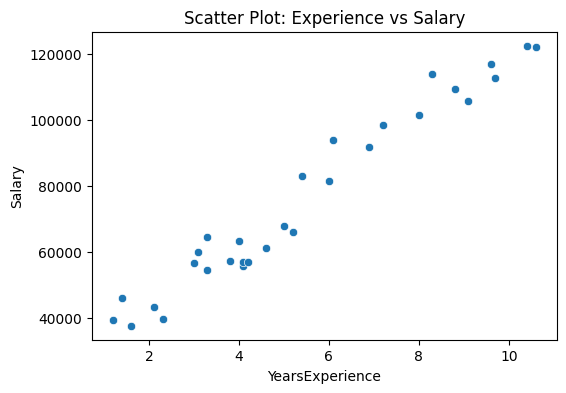

In [14]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='YearsExperience', y='Salary', data=df)
plt.title("Scatter Plot: Experience vs Salary")
plt.show()


### **Plot a trend line between Years of Experience and Salary**

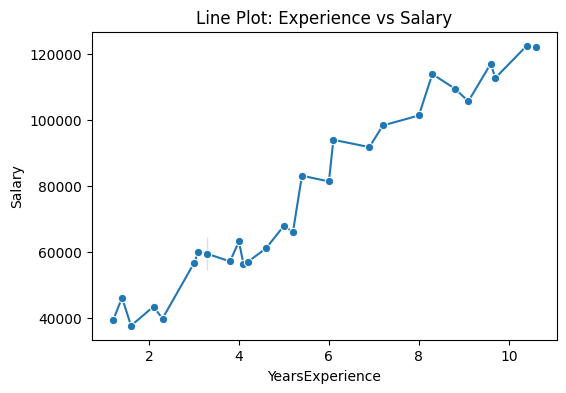

In [15]:
plt.figure(figsize=(6,4))
sns.lineplot(x='YearsExperience', y='Salary', data=df, marker='o')
plt.title("Line Plot: Experience vs Salary")
plt.show()

### **Plots the distribution of salaries as a histogram with 10 bins and a smooth KDE curve, labeled with a title and x-axis name.**

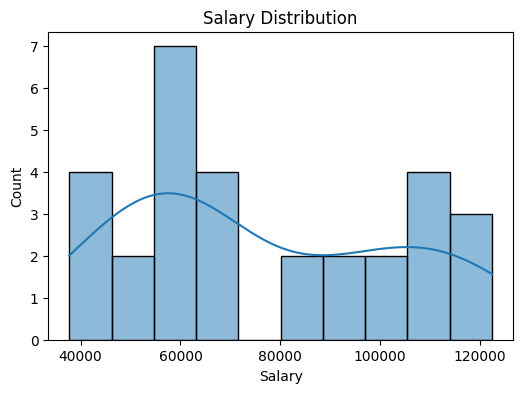

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(df['Salary'], kde=True, bins=10)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.show()

### **Compute the correlation matrix of the DataFrame and visualizes it as a color-coded heatmap with numeric annotations.**

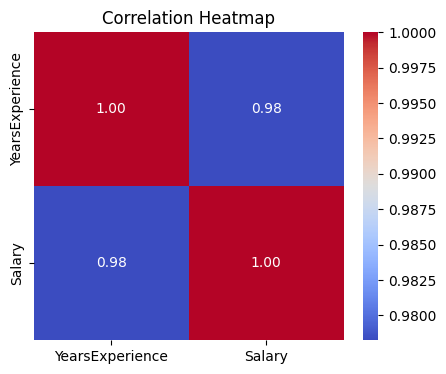

In [17]:
corr = df.corr()
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Now, let's split our dataset into features and target variable:

**X → independent variables (features)**

**y → dependent variable (target)**

This step is called selecting features and target for our model.

In [20]:
X = df.drop('Salary',axis=1)
y = df['Salary']

**After splitting the dataset into X (features) and y (target), the next step is to train our model on a portion of the data.**
Use train_test_split from skelearn.model_selection

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

**We know this no that `K-Nearest Neighbors (KNN)` is an algorithm that relies on distance between points. If the features are on different scales, the algorithm may give more importance to features with larger values, which can distort the results.** 
we use StandardScaler to scale the features so that all of them contribute equally.

In [26]:
from sklearn.preprocessing import StandardScaler
scaled = StandardScaler()
X_train = scaled.fit_transform(X_train)
X_test = scaled.transform(X_test)

### Now, let's create a KNN regression model using sklearn.neighbors"

In [34]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=3)

### Train X and y feature

In [35]:
model.fit(X_train,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Make prediction on X_test

In [36]:
y_pred = model.predict(X_test)

### Finally, we have created our KNN model, trained it on X_train and y_train, and made predictions. Now, let's evaluate how well the model is performing using the R² score.

In [37]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9407212188647607

### We vary n_neighbors from 1 to 15, train KNN each time, record the R² score, and pick the value that gives the best performance.

In [32]:
scores = []
for i in range(1,16):
    model = KNeighborsRegressor(n_neighbors=i)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    scores.append(r2_score(y_test,y_pred))

### We plot n_neighbors (1–15) on the x-axis against their R² scores on the y-axis to visualize performance changes.

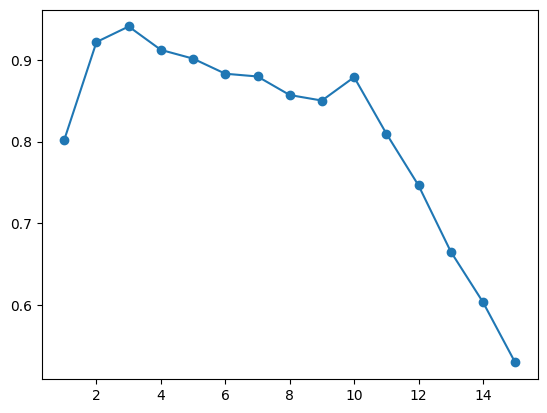

In [33]:
plt.plot(range(1,16),scores,marker="o")